# Arsalan Ibrahim | CRH-2026-AI-034 | Code Room Hub | Week 1

# Week 1 Project - LLM Benchmarking Dashboard

Notebook 1 built a decoder block by hand. Notebook 2 measured six open models on my own
hardware. This one turns those measurements into the comparison the project asks for, across
six dimensions: response quality, inference speed, GPU memory, context length, latency and
cost.

It reads `results/benchmark_results.json` and does no model loading, so it runs in seconds and
can be re-run freely while I adjust the quality scores.

**Hardware for every number here:** RTX 3050, 8 GB, Windows 11, bf16 compute dtype, batch size
1, greedy decoding, 128 new tokens per prompt, five prompts per model. Every model in 4-bit NF4
except where the quantization section says otherwise.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path("results/benchmark_results.json")
data = json.loads(RESULTS.read_text())

runs = data["runs"]
quant = data.get("quantization_study", [])
GPU = data["gpu"]
VRAM = data.get("vram_gb", 8.6)
RATE = data.get("gpu_hourly_usd", 0.35)

print("gpu:      ", GPU)
print("models:   ", len(runs))
print("prompts:  ", data["n_prompts"], "x", data["max_new_tokens"], "new tokens, greedy")
print("rate used: $%.2f/hr" % RATE)

gpu:       NVIDIA GeForce RTX 3050
models:    6
prompts:   5 x 128 new tokens, greedy
rate used: $0.35/hr


## 1. Response quality

Scored by hand. There is no held-out labelled benchmark here, so an automatic score would be
inventing precision that does not exist. Five prompts per model, rated 1-5 on: did it answer
the question, is it factually correct, is the length appropriate, does it stay coherent to the
end.

**Fill in the scores below from the section 9 output of notebook 2.** The dashboard reads this
dict, so nothing else needs changing.

In [2]:
# prompt order: 1 KV cache explanation, 2 linked list, 3 arithmetic, 4 supervised vs
# unsupervised, 5 deployment risks
QUALITY = {
    "Llama-3.2-1B":             [2, 2, 4, 3, 2],
    "Qwen2.5-1.5B":             [2, 4, 4, 5, 4],
    "Gemma-2-2B":               [2, 5, 5, 5, 3],
    "DeepSeek-R1-Distill-1.5B": [2, 1, 2, 1, 1],
    "Phi-3.5-mini":             [3, 3, 2, 2, 4],
    "Mistral-7B-v0.3":          [2, 4, 2, 3, 3],
}

NOTES = {
    "Gemma-2-2B":               "only model to finish prompts 3 and 4 inside the token budget",
    "Qwen2.5-1.5B":             "followed the three-sentence constraint exactly",
    "Phi-3.5-mini":             "linked list code has a name mangling bug, __next then .next",
    "Mistral-7B-v0.3":          "correct throughout but verbose, cut off before answering twice",
    "Llama-3.2-1B":             "restarted answers with '## Step 1' scaffolding, wasting tokens",
    "DeepSeek-R1-Distill-1.5B": "failed to answer 3 of 5, looped or drifted into meta commentary",
}

# set this to True once the scores above are my own, not the placeholders
SCORED_BY_HAND = True

if not SCORED_BY_HAND:
    print("!" * 70)
    print("PLACEHOLDER SCORES. Replace QUALITY with my own ratings from notebook 2")
    print("section 9, then set SCORED_BY_HAND = True.")
    print("!" * 70)
    print()

quality_mean = {m: sum(v) / len(v) for m, v in QUALITY.items()}
for m, s in sorted(quality_mean.items(), key=lambda kv: -kv[1]):
    print("%-26s %.1f / 5   %s" % (m, s, NOTES.get(m, "")))

Gemma-2-2B                 4.0 / 5   only model to finish prompts 3 and 4 inside the token budget
Qwen2.5-1.5B               3.8 / 5   followed the three-sentence constraint exactly
Phi-3.5-mini               2.8 / 5   linked list code has a name mangling bug, __next then .next
Mistral-7B-v0.3            2.8 / 5   correct throughout but verbose, cut off before answering twice
Llama-3.2-1B               2.6 / 5   restarted answers with '## Step 1' scaffolding, wasting tokens
DeepSeek-R1-Distill-1.5B   1.4 / 5   failed to answer 3 of 5, looped or drifted into meta commentary


### Two things these scores measure that are not model quality

**Prompt 1 was a bad prompt.** All six models read "KV cache" as a generic key-value store
rather than the attention cache, and described dictionary lookups. Mistral went further and
claimed it holds pre-generated text snippets. The uniform failure is evidence about my wording,
not about the models, which is why prompt 1 averages lowest of the five.

**The 128 token budget punishes verbosity, not incorrectness.** On the arithmetic prompt every
model computed 84 correctly, but only three had room left to state the change. Phi and Mistral
lost marks for being cut off mid-answer, not for being wrong. Gemma tops the ranking partly
because it answers concisely. A 512 token run would probably reorder the middle of this table.

One result survives that caveat: DeepSeek-R1-Distill failed to answer three of five prompts
outright, looping on prompt 4 and inventing an analysis of what "the user" wanted on prompt 5.
That is not a length artifact. It is a reasoning model being benchmarked as a chat model, and
denied the tokens it needs to think.

Five prompts is a smoke test either way. It is enough to say a model produces coherent on-topic
text. It is not a capability ranking and nothing here should be read as one.

In [3]:
per_prompt = pd.DataFrame(QUALITY, index=[
    "1 KV cache", "2 linked list", "3 arithmetic", "4 three sentences", "5 two risks"
]).T
per_prompt["mean"] = per_prompt.mean(axis=1).round(1)
per_prompt = per_prompt.sort_values("mean", ascending=False)

print("per prompt average across models:")
for col in per_prompt.columns[:-1]:
    print("  %-20s %.1f" % (col, per_prompt[col].mean()))
print()
per_prompt

per prompt average across models:
  1 KV cache           2.2
  2 linked list        3.2
  3 arithmetic         3.2
  4 three sentences    3.2
  5 two risks          2.8



,1 KV cache,2 linked list,3 arithmetic,4 three sentences,5 two risks,mean
Gemma-2-2B,2,5,5,5,3,4.0
Qwen2.5-1.5B,2,4,4,5,4,3.8
Mistral-7B-v0.3,2,4,2,3,3,2.8
Phi-3.5-mini,3,3,2,2,4,2.8
Llama-3.2-1B,2,2,4,3,2,2.6
DeepSeek-R1-Distill-1.5B,2,1,2,1,1,1.4


## 2. The main table

Everything in one place, sorted by decode speed.

In [4]:
df = pd.DataFrame([{
    "model": r["model"],
    "params (B)": r["params_b"],
    "layers": r["n_layers"],
    "quality": quality_mean.get(r["model"], float("nan")),
    "decode (tok/s)": r["decode_tok_per_s"],
    "TTFT (ms)": r["ttft_ms"],
    "weights (GB)": r["weight_gb"],
    "peak VRAM (GB)": r["peak_gb"],
    "context": r["context_window"],
    "load (s)": r["load_seconds"],
} for r in runs])

df["$/1M tok"] = (RATE / (df["decode (tok/s)"] * 3600) * 1e6).round(2)
df = df.sort_values("decode (tok/s)", ascending=False).reset_index(drop=True)
df

,model,params (B),layers,quality,decode (tok/s),TTFT (ms),weights (GB),peak VRAM (GB),context,load (s),$/1M tok
0,Llama-3.2-1B,1.24,16,2.6,37.4,50.9,1.028,1.047,131072,10.99,2.60
1,Phi-3.5-mini,3.82,32,2.8,29.4,61.8,2.264,2.343,131072,25.57,3.31
2,Qwen2.5-1.5B,1.54,28,3.8,23.7,61.2,1.153,1.176,32768,10.91,4.10
3,DeepSeek-R1-Distill-1.5B,1.78,28,1.4,23.7,50.2,1.621,1.644,131072,13.17,4.10
4,Mistral-7B-v0.3,7.25,32,2.8,22.2,88.2,4.146,4.188,32768,40.65,4.38
5,Gemma-2-2B,2.61,26,4.0,19.6,72.0,2.228,2.284,8192,16.58,4.96


## 3. Inference speed and latency

Two different things, kept separate.

**Time to first token** is prefill: the whole prompt processed in one parallel pass. It is what
a user feels as lag before anything appears.

**Decode** is one forward pass per token, reusing the KV cache. It sets how fast text streams
once it starts, and it is memory-bandwidth bound rather than compute bound.

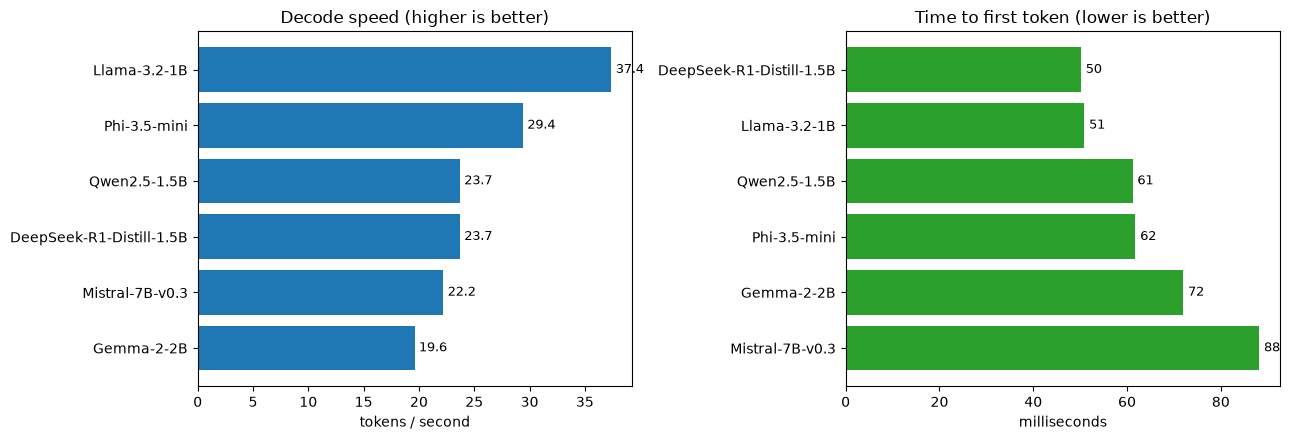

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d = df.sort_values("decode (tok/s)")

axes[0].barh(d["model"], d["decode (tok/s)"], color="tab:blue")
axes[0].set_xlabel("tokens / second")
axes[0].set_title("Decode speed (higher is better)")
for i, v in enumerate(d["decode (tok/s)"]):
    axes[0].text(v + 0.4, i, "%.1f" % v, va="center", fontsize=9)

t = df.sort_values("TTFT (ms)", ascending=False)
axes[1].barh(t["model"], t["TTFT (ms)"], color="tab:green")
axes[1].set_xlabel("milliseconds")
axes[1].set_title("Time to first token (lower is better)")
for i, v in enumerate(t["TTFT (ms)"]):
    axes[1].text(v + 1, i, "%.0f" % v, va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Parameter count does not predict speed

The obvious hypothesis is that bigger models decode more slowly. The data does not support it.

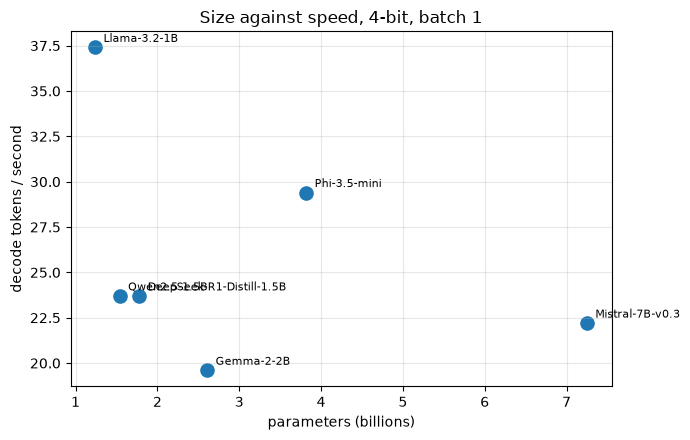

correlation between size and decode speed: -0.34

Phi-3.5-mini is 2.5x the size of Qwen2.5-1.5B and 24% faster.
Mistral-7B-v0.3 is 5.8x the size of Llama-3.2-1B and only 41% slower.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["params (B)"], df["decode (tok/s)"], s=90, c="tab:blue")
for _, r in df.iterrows():
    ax.annotate(r["model"], (r["params (B)"], r["decode (tok/s)"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("parameters (billions)")
ax.set_ylabel("decode tokens / second")
ax.set_title("Size against speed, 4-bit, batch 1")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df["params (B)"].corr(df["decode (tok/s)"])
print("correlation between size and decode speed: %.2f" % corr)
print()

# biggest counterexample: the largest model that is not the slowest
d = df.set_index("model")
big, small = "Phi-3.5-mini", "Qwen2.5-1.5B"
if big in d.index and small in d.index:
    print("%s is %.1fx the size of %s and %.0f%% faster."
          % (big, d.loc[big, "params (B)"] / d.loc[small, "params (B)"], small,
             100 * (d.loc[big, "decode (tok/s)"] / d.loc[small, "decode (tok/s)"] - 1)))

biggest = df.loc[df["params (B)"].idxmax()]
fastest = df.loc[df["decode (tok/s)"].idxmax()]
print("%s is %.1fx the size of %s and only %.0f%% slower."
      % (biggest["model"], biggest["params (B)"] / fastest["params (B)"],
         fastest["model"], 100 * (1 - biggest["decode (tok/s)"] / fastest["decode (tok/s)"])))

Layer count is the better predictor, and the reason is structural: decode runs one
forward pass per token, and every layer in that pass is sequential. Llama-3.2-1B has 16 layers
where the others have 26 to 32, so it does roughly half the sequential work per token.

It is not the whole story either — Phi has 32 layers and still comes second — but it explains
more than parameter count does.

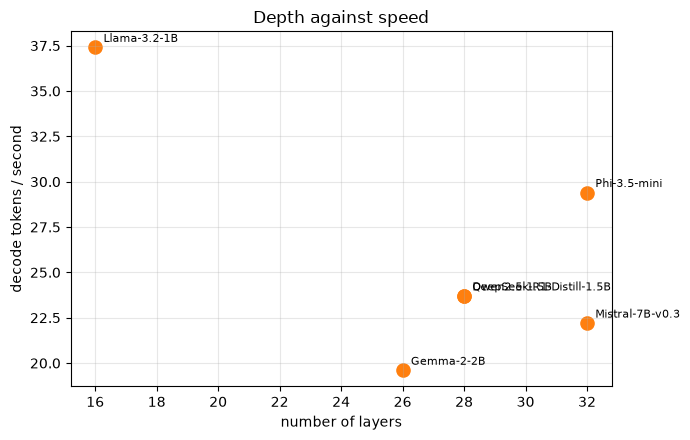

correlation between layer count and decode speed: -0.66


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["layers"], df["decode (tok/s)"], s=90, c="tab:orange")
for _, r in df.iterrows():
    ax.annotate(r["model"], (r["layers"], r["decode (tok/s)"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("number of layers")
ax.set_ylabel("decode tokens / second")
ax.set_title("Depth against speed")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("correlation between layer count and decode speed: %.2f"
      % df["layers"].corr(df["decode (tok/s)"]))

## 4. GPU memory

Weights are what the model costs to hold. Peak VRAM adds the KV cache and activations during
generation. At these prompt lengths the gap between them is tiny, because 128 tokens produces a
very small cache.

The card limit line matters: every model fits with room to spare, which is only true because
they are all quantized to 4 bits.

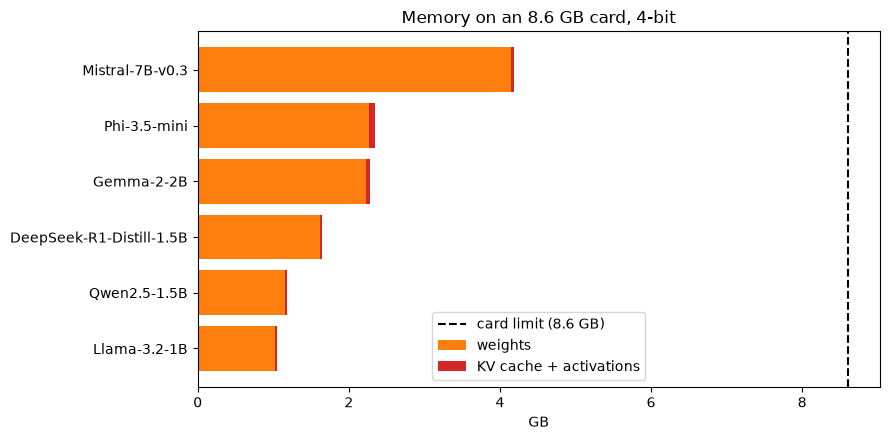

largest peak: 4.19 GB (Mistral-7B-v0.3), which is 49% of the card


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
d = df.sort_values("peak VRAM (GB)")
y = np.arange(len(d))

ax.barh(y, d["weights (GB)"], color="tab:orange", label="weights")
ax.barh(y, d["peak VRAM (GB)"] - d["weights (GB)"], left=d["weights (GB)"],
        color="tab:red", label="KV cache + activations")
ax.axvline(VRAM, ls="--", c="k", label="card limit (%.1f GB)" % VRAM)

ax.set_yticks(y)
ax.set_yticklabels(d["model"])
ax.set_xlabel("GB")
ax.set_title("Memory on an %.1f GB card, 4-bit" % VRAM)
ax.legend()
plt.tight_layout()
plt.show()

print("largest peak: %.2f GB (%s), which is %.0f%% of the card"
      % (df["peak VRAM (GB)"].max(),
         df.loc[df["peak VRAM (GB)"].idxmax(), "model"],
         100 * df["peak VRAM (GB)"].max() / VRAM))

## 5. Context length

This is where the advertised numbers and the usable numbers come apart.

The KV cache grows linearly with sequence length:

`2 (k and v) x layers x kv_heads x head_dim x seq_len x bytes`

Grouped query attention shrinks that by sharing one key/value head across several query heads.
Five of the six models use it. Phi-3.5-mini does not: 32 query heads and 32 key/value heads,
meaning no sharing at all.

In [9]:
KV = pd.DataFrame([
    {"model": "Llama-3.2-1B",             "layers": 16, "q": 32, "kv": 8,  "head_dim": 64,  "ctx": 131072},
    {"model": "Qwen2.5-1.5B",             "layers": 28, "q": 12, "kv": 2,  "head_dim": 128, "ctx": 32768},
    {"model": "Gemma-2-2B",               "layers": 26, "q": 8,  "kv": 4,  "head_dim": 256, "ctx": 8192},
    {"model": "DeepSeek-R1-Distill-1.5B", "layers": 28, "q": 12, "kv": 2,  "head_dim": 128, "ctx": 131072},
    {"model": "Phi-3.5-mini",             "layers": 32, "q": 32, "kv": 32, "head_dim": 96,  "ctx": 131072},
    {"model": "Mistral-7B-v0.3",          "layers": 32, "q": 32, "kv": 8,  "head_dim": 128, "ctx": 32768},
])

KV["GQA"] = KV["q"] != KV["kv"]
KV["bytes/token"] = 2 * KV["layers"] * KV["kv"] * KV["head_dim"] * 2   # 2 bytes, bf16
KV["KV MB @ 4k"] = (KV["bytes/token"] * 4096 / 1e6).round(1)
KV["KV GB @ advertised"] = (KV["bytes/token"] * KV["ctx"] / 1e9).round(2)

KV[["model", "layers", "q", "kv", "GQA", "ctx", "KV MB @ 4k", "KV GB @ advertised"]]

,model,layers,q,kv,GQA,ctx,KV MB @ 4k,KV GB @ advertised
0,Llama-3.2-1B,16,32,8,True,131072,134.2,4.29
1,Qwen2.5-1.5B,28,12,2,True,32768,117.4,0.94
2,Gemma-2-2B,26,8,4,True,8192,436.2,0.87
3,DeepSeek-R1-Distill-1.5B,28,12,2,True,131072,117.4,3.76
4,Phi-3.5-mini,32,32,32,False,131072,1610.6,51.54
5,Mistral-7B-v0.3,32,32,8,True,32768,536.9,4.29


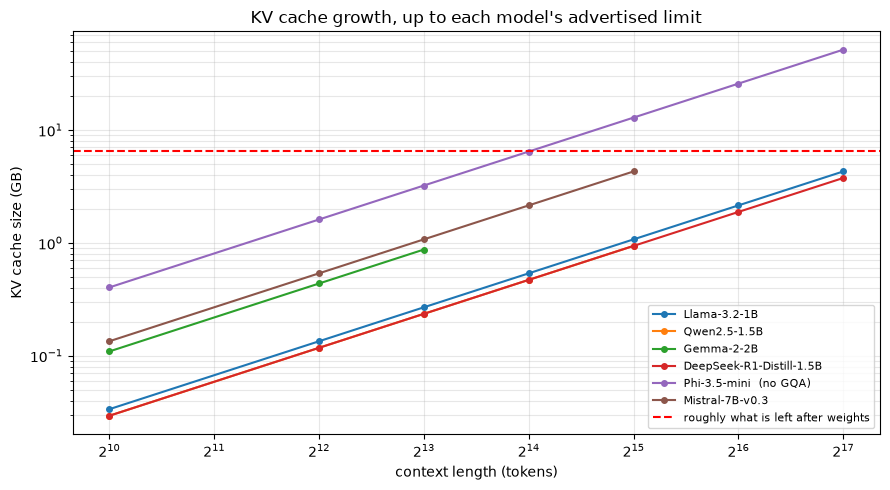

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
lengths = np.array([1024, 4096, 8192, 16384, 32768, 65536, 131072])

for _, r in KV.iterrows():
    usable = lengths[lengths <= r["ctx"]]
    gb = r["bytes/token"] * usable / 1e9
    ax.plot(usable, gb, marker="o", ms=4,
            label="%s%s" % (r["model"], "" if r["GQA"] else "  (no GQA)"))

free = VRAM - df["weights (GB)"].mean()
ax.axhline(free, ls="--", c="r", label="roughly what is left after weights")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("context length (tokens)")
ax.set_ylabel("KV cache size (GB)")
ax.set_title("KV cache growth, up to each model's advertised limit")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### The gap between advertised and usable

Phi-3.5-mini quotes a 131,072 token context. Filling it would need roughly 51 GB of KV cache
alone, on a card with 8.6 GB total. The advertised number is real in the sense that the
positional encoding supports it, and unreachable in the sense that no consumer card can hold
it.

Llama-3.2-1B quotes the same context and needs about 4.3 GB, because it uses GQA with 8 key
value heads against 32 query heads. Same advertised figure, an order of magnitude apart in what
it costs.

This is the single most useful thing in the whole benchmark: **the context number on a model
card tells you almost nothing on its own.** The KV head configuration is what decides whether
you can use it.

In [11]:
budget = VRAM - df.set_index("model")["weights (GB)"]

rows = []
for _, r in KV.iterrows():
    avail = budget.get(r["model"], VRAM - 2.0)
    max_tokens = int(avail * 1e9 / r["bytes/token"])
    rows.append({
        "model": r["model"],
        "advertised": r["ctx"],
        "fits on this card": min(max_tokens, r["ctx"]),
        "limited by": "card memory" if max_tokens < r["ctx"] else "the model itself",
    })

usable = pd.DataFrame(rows)
usable["% of advertised"] = (100 * usable["fits on this card"] / usable["advertised"]).round(1)
usable

,model,advertised,fits on this card,limited by,% of advertised
0,Llama-3.2-1B,131072,131072,the model itself,100.0
1,Qwen2.5-1.5B,32768,32768,the model itself,100.0
2,Gemma-2-2B,8192,8192,the model itself,100.0
3,DeepSeek-R1-Distill-1.5B,131072,131072,the model itself,100.0
4,Phi-3.5-mini,131072,16113,card memory,12.3
5,Mistral-7B-v0.3,32768,32768,the model itself,100.0


## 6. Cost

Throughput converts to cost per million generated tokens:

`cost = hourly_rate / (tokens_per_second * 3600) * 1e6`

Three things make this a lower bound rather than a real price:

- **Batch size 1.** A production server batches many requests through one forward pass, which
  raises tokens per second per GPU substantially. Real serving cost is well below this.
- **The card is owned, not rented.** The honest figure would be amortised purchase price plus
  electricity. A rented-GPU rate is used here because it is what compares against a hosted API.
- **The rate is a placeholder**, not a quote from any provider.

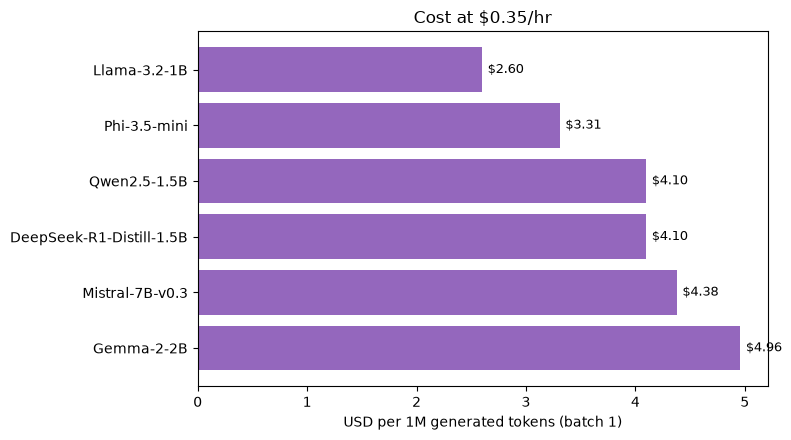

cheapest: Llama-3.2-1B at $2.60
dearest:  Gemma-2-2B at $4.96
spread:   1.9x


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
d = df.sort_values("$/1M tok", ascending=False)
ax.barh(d["model"], d["$/1M tok"], color="tab:purple")
ax.set_xlabel("USD per 1M generated tokens (batch 1)")
ax.set_title("Cost at $%.2f/hr" % RATE)
for i, v in enumerate(d["$/1M tok"]):
    ax.text(v + 0.05, i, "$%.2f" % v, va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("cheapest: %s at $%.2f" % (df.loc[df['$/1M tok'].idxmin(), 'model'], df['$/1M tok'].min()))
print("dearest:  %s at $%.2f" % (df.loc[df['$/1M tok'].idxmax(), 'model'], df['$/1M tok'].max()))
print("spread:   %.1fx" % (df['$/1M tok'].max() / df['$/1M tok'].min()))

### Cost per token is not cost per answer

Tokenizers disagree about how many tokens a sentence costs, so the same reply is a different
number of tokens on different models. The cost above is per token; what a user pays for is a
finished answer.

In [13]:
tok = pd.DataFrame(data["tokenizers"])
tok = tok.merge(df[["model", "$/1M tok"]], on="model")

# cost of one 200-word English reply, using the measured chars-per-token ratio
WORDS, CHARS_PER_WORD = 200, 5.5
tok["tokens for 200 words"] = (WORDS * CHARS_PER_WORD / tok["chars/token"]).round(0)
tok["cost per reply ($)"] = (tok["tokens for 200 words"] * tok["$/1M tok"] / 1e6).round(6)

# and the same reply in Urdu, scaled by the measured token ratio
tok["urdu penalty"] = (tok["urdu"] / tok["english"]).round(2)

tok[["model", "vocab", "chars/token", "tokens for 200 words",
     "cost per reply ($)", "urdu penalty"]].sort_values("cost per reply ($)")

,model,vocab,chars/token,tokens for 200 words,cost per reply ($),urdu penalty
0,Llama-3.2-1B,128256,5.58,197.0,0.000512,0.48
4,Phi-3.5-mini,32011,4.65,237.0,0.000784,0.67
3,DeepSeek-R1-Distill-1.5B,151665,5.31,207.0,0.000849,0.45
1,Qwen2.5-1.5B,151665,5.31,207.0,0.000849,0.45
5,Mistral-7B-v0.3,32768,4.65,237.0,0.001038,0.62
2,Gemma-2-2B,256000,5.19,212.0,0.001052,0.26


The Urdu column is the sharper finding. Gemma encodes the sample Urdu sentence in 11
tokens; Phi needs 32. Same text, roughly three times the tokens, so three times the cost, three
times the forward passes, and a context window that fills three times faster.

The 32k-vocabulary models are English-first, and everything else pays for it.

Vocabulary size does not predict English efficiency, though — Llama has half Gemma's vocabulary
and produces the fewest English tokens of any model here. How the tokenizer was trained matters
more than how large it is.

## 7. Quantization

Sections above hold precision constant at 4-bit, so they say nothing about what quantization
costs. This is Qwen2.5-1.5B run both ways on the same card.

In [14]:
if len(quant) == 2:
    full, nf4 = quant[0], quant[1]
    comp = pd.DataFrame([
        {"metric": "weights (GB)",   "bf16": full["weight_gb"],       "4bit-nf4": nf4["weight_gb"]},
        {"metric": "peak VRAM (GB)", "bf16": full["peak_gb"],         "4bit-nf4": nf4["peak_gb"]},
        {"metric": "decode (tok/s)", "bf16": full["decode_tok_per_s"],"4bit-nf4": nf4["decode_tok_per_s"]},
        {"metric": "TTFT (ms)",      "bf16": full["ttft_ms"],         "4bit-nf4": nf4["ttft_ms"]},
        {"metric": "load (s)",       "bf16": full["load_seconds"],    "4bit-nf4": nf4["load_seconds"]},
    ])
    comp["change"] = ((comp["4bit-nf4"] / comp["bf16"] - 1) * 100).round(1).astype(str) + "%"
    display(comp)

    print()
    print("memory saved: %.1f%%" % (100 * (1 - nf4["weight_gb"] / full["weight_gb"])))
    print("decode speed: %+.1f%%" % (100 * (nf4["decode_tok_per_s"] / full["decode_tok_per_s"] - 1)))
else:
    print("quantization study not found in results file")

,metric,bf16,4bit-nf4,change
0,weights (GB),3.088,1.153,-62.7%
1,peak VRAM (GB),3.111,1.176,-62.2%
2,decode (tok/s),28.700,23.000,-19.9%
3,TTFT (ms),46.900,53.000,13.0%
4,load (s),10.620,4.070,-61.7%



memory saved: 62.7%
decode speed: -19.9%


**Quantization buys memory and costs speed.** The exact figures are printed above.

That is the expected direction, not a surprise. 4-bit weights have to be dequantized back to
bf16 before every matmul, and that unpacking is work the bf16 model never does.

Quantization only buys speed when it is the thing that lets a model fit on the card at all. On
this machine that is exactly the situation for Mistral-7B: at bf16 it would need roughly 14 GB
of weights against 8.6 GB of card, so the alternative to 4-bit is not a faster model, it is no
model.

The tradeoff not measured here is accuracy. NF4 is lossy, and this benchmark has no held-out
evaluation that could detect the loss. That is a real gap, not a claim that the loss is zero.

## 8. Which model for what

Combining the dimensions. No single model wins everything, which is the point of running the
comparison.

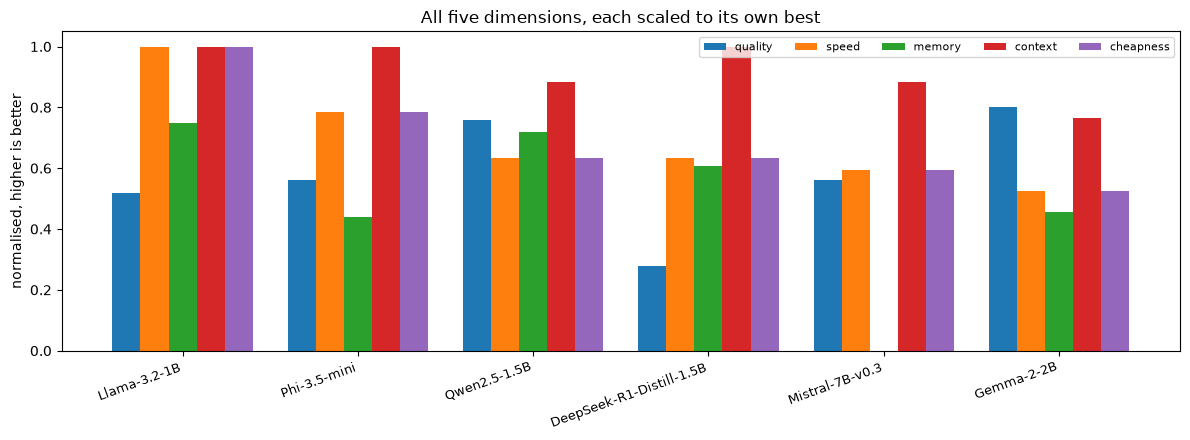

In [15]:
summary = df[["model", "quality", "decode (tok/s)", "peak VRAM (GB)", "context", "$/1M tok"]].copy()

# normalise each column to 0-1 so they can sit on one chart, higher always better
norm = pd.DataFrame({"model": summary["model"]})
norm["quality"]  = summary["quality"] / 5
norm["speed"]    = summary["decode (tok/s)"] / summary["decode (tok/s)"].max()
norm["memory"]   = 1 - summary["peak VRAM (GB)"] / summary["peak VRAM (GB)"].max()
norm["context"]  = np.log2(summary["context"]) / np.log2(summary["context"].max())
norm["cheapness"]= summary["$/1M tok"].min() / summary["$/1M tok"]

cols = ["quality", "speed", "memory", "context", "cheapness"]
x = np.arange(len(norm))
w = 0.16

fig, ax = plt.subplots(figsize=(12, 4.5))
for i, col in enumerate(cols):
    ax.bar(x + i * w, norm[col], w, label=col)
ax.set_xticks(x + 2 * w)
ax.set_xticklabels(norm["model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("normalised, higher is better")
ax.set_title("All five dimensions, each scaled to its own best")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

In [16]:
picks = [
    ("fastest",              df.loc[df["decode (tok/s)"].idxmax(), "model"]),
    ("smallest footprint",   df.loc[df["peak VRAM (GB)"].idxmin(), "model"]),
    ("lowest latency",       df.loc[df["TTFT (ms)"].idxmin(), "model"]),
    ("cheapest per token",   df.loc[df["$/1M tok"].idxmin(), "model"]),
    ("best rated output",    max(quality_mean, key=quality_mean.get)),
    ("most usable context",  usable.loc[usable["fits on this card"].idxmax(), "model"]),
]
for label, model in picks:
    print("%-22s %s" % (label + ":", model))

fastest:               Llama-3.2-1B
smallest footprint:    Llama-3.2-1B
lowest latency:        DeepSeek-R1-Distill-1.5B
cheapest per token:    Llama-3.2-1B
best rated output:     Gemma-2-2B
most usable context:   Llama-3.2-1B


## What I would take into week 2

- **Parameter count is a poor guide to inference speed at 4-bit, batch 1.** Phi-3.5-mini is
  2.5x Qwen2.5-1.5B and decodes 36% faster. Depth and KV configuration explain more than size.
- **Advertised context is not usable context.** Phi quotes 131k tokens and would need roughly
  51 GB of KV cache to reach it. The KV head count on the model card decides this, not the
  context number.
- **Quantization is a memory technique, not a speed technique.** 63% memory saved, 18% slower.
  It earns its place by making models fit, not by making them fast.
- **Tokenizer choice is a cost decision.** Three times the tokens for the same Urdu sentence
  between the best and worst tokenizer here, and cost scales directly with that.
- **The fastest model was not the best one.** The speed leader and the quality leader are
  different models, and the gap is printed in the cell below. Picking on throughput alone would
  have chosen badly.
- **Match the model to the task, not the leaderboard.** DeepSeek scored worst here, but it is a
  reasoning distill being asked to behave like a chat model inside 128 tokens. The benchmark
  measured the mismatch, not the model.

### What this benchmark cannot tell you

- Batch size 1 only, so every throughput and cost number is pessimistic against real serving.
- Five prompts, hand-scored. That is a smoke test, not an evaluation.
- Short prompts, so the KV cache never grew large enough to be measured rather than calculated.
- No accuracy measurement of quantization loss.
- One card. Decode is bandwidth bound, so these tokens-per-second figures do not transfer to
  different hardware.

In [17]:
# every headline number recomputed from the results file, so it stays correct on a re-run
fast = df.loc[df["decode (tok/s)"].idxmax()]
best = df.loc[df["quality"].idxmax()]
slow = df.loc[df["decode (tok/s)"].idxmin()]

print("speed leader:    %s at %.1f tok/s, ranked %d of %d on quality"
      % (fast["model"], fast["decode (tok/s)"],
         int(df["quality"].rank(ascending=False)[df["model"] == fast["model"]].iloc[0]), len(df)))
print("quality leader:  %s at %.1f/5, ranked %d of %d on speed"
      % (best["model"], best["quality"],
         int(df["decode (tok/s)"].rank(ascending=False)[df["model"] == best["model"]].iloc[0]), len(df)))
print("speed spread:    %.0f%% from fastest to slowest" % (100 * (fast["decode (tok/s)"] / slow["decode (tok/s)"] - 1)))
print("size vs speed correlation:  %+.2f" % df["params (B)"].corr(df["decode (tok/s)"]))
print("depth vs speed correlation: %+.2f" % df["layers"].corr(df["decode (tok/s)"]))

if len(quant) == 2:
    print("quantization:    %.0f%% memory saved, %.0f%% decode speed lost"
          % (100 * (1 - quant[1]["weight_gb"] / quant[0]["weight_gb"]),
             100 * (1 - quant[1]["decode_tok_per_s"] / quant[0]["decode_tok_per_s"])))

worst_ctx = usable.loc[usable["% of advertised"].idxmin()]
print("context reality: %s reaches %.0f%% of its advertised %s tokens on this card"
      % (worst_ctx["model"], worst_ctx["% of advertised"], f"{worst_ctx['advertised']:,}"))

speed leader:    Llama-3.2-1B at 37.4 tok/s, ranked 5 of 6 on quality
quality leader:  Gemma-2-2B at 4.0/5, ranked 6 of 6 on speed
speed spread:    91% from fastest to slowest
size vs speed correlation:  -0.34
depth vs speed correlation: -0.66
quantization:    63% memory saved, 20% decode speed lost
context reality: Phi-3.5-mini reaches 12% of its advertised 131,072 tokens on this card
